In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from Bio import SeqIO
import os
from collections import Counter

import statsmodels.stats as sm


from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

from matplotlib_venn import venn2
plt.rcParams.update({'font.size': 30, 'font.family':'Arial'})



### Select most prevalent VMGC species

In [2]:
base_dir = '/Users/cdubin/Library/CloudStorage/Box-Box/VMGC_cervical_dysplasia_paper/code/'

In [3]:
metadata = pd.read_csv(f'{base_dir}/cervical_dysplasia/metadata/metadata.csv', index_col=0)
metadata.shape

(354, 24)

In [4]:
vmgc_rel_abund = pd.read_csv(f'{base_dir}/cervical_dysplasia/MIDAS3/VMGC_ref/results_C90/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
vmgc_rel_abund = vmgc_rel_abund[vmgc_rel_abund.columns.intersection(metadata.index)]
vmgc_rel_abund


,Dysp_0088,Dysp_0067,Dysp_0021,Dysp_0043,Dysp_0079,Dysp_0022,Dysp_0029,Dysp_0083,Dysp_0027,Dysp_0069,...,Dysp_0050,Dysp_0071,VMG_0098,Dysp_0053,VMG_0025,VMG_0019,Dysp_0174,VMG_0070,Dysp_0164,VMG_0108
species_id,,,,,,,,,,,,,,,,,,,,,
988598,0.975,0.000,0.000,0.000,0.979,0.874,0.0,0.586,0.000,0.000,...,0.000,0.000,0.991,0.000,1.0,0.000,0.000,0.007,0.438,0.000
571325,0.015,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,...,0.000,0.000,0.005,0.000,0.0,0.000,0.000,0.000,0.083,0.000
240891,0.008,0.962,0.099,0.003,0.018,0.000,0.0,0.000,0.000,0.992,...,0.000,0.000,0.000,0.000,0.0,0.001,0.030,0.018,0.009,0.000
559158,0.001,0.032,0.000,0.000,0.000,0.001,0.0,0.000,0.000,0.008,...,0.000,0.000,0.003,0.000,0.0,0.000,0.000,0.000,0.002,0.000
783244,0.000,0.000,0.602,0.111,0.000,0.001,0.0,0.224,0.774,0.000,...,0.044,0.538,0.000,0.077,0.0,0.418,0.635,0.092,0.000,0.592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281411,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
473111,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
295887,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000


In [5]:
sp_names = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/genomes_and_SGBs.csv')
sp_names['species'].nunique(), sp_names['species_name'].nunique(), 

(544, 544)

In [6]:
vmgc_prev = (vmgc_rel_abund >= 0.05).astype(int)
vmgc_prev = vmgc_prev[vmgc_prev.sum(axis=1) >= metadata.shape[0]*0.05]
vmgc_most_prev = vmgc_prev.sum(axis=1).sort_values(ascending=False).to_frame(name='num_samples')
vmgc_most_prev['species'] = vmgc_most_prev.index.astype(int).map(sp_names.drop_duplicates('species').set_index('species')['species_name'])
vmgc_most_prev

,num_samples,species
species_id,,
988598,135,Lactobacillus crispatus
240891,121,Lactobacillus iners
783244,78,Bifidobacterium vaginale
976363,64,Bifidobacterium leopoldii
367459,56,Bifidobacterium swidsinskii
619501,43,Fannyhessea vaginae
379267,42,Fannyhessea_unknown
571325,35,Lactobacillus jensenii
595185,25,Bifidobacterium piotii


### Plots for most prevalent VMGC species

In [7]:
code_to_name = sp_names.drop_duplicates('species').set_index('species')['species_name'].to_dict()
name_to_code = sp_names.drop_duplicates('species_name').set_index('species_name')['species'].to_dict()

In [8]:
rel_abund = vmgc_rel_abund.T

In [9]:
color_dict_mine = {'Bifidobacterium leopoldii':'powderblue', 
              'Bifidobacterium piotii':'mediumturquoise', 
              'Bifidobacterium swidsinskii':'dodgerblue', 
              'Bifidobacterium vaginale':'navy', 
              'Fannyhessea vaginae':'teal', 
              'Fannyhessea_unknown':'darkolivegreen', 
              'Lactobacillus crispatus':'hotpink', 
              'Lactobacillus gasseri':'orangered', 
              'Lactobacillus iners':'goldenrod',
                'Lactobacillus jensenii':'darkmagenta', 
                'Megasphaera lornae':'chocolate'}


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/1811741318.py:124: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


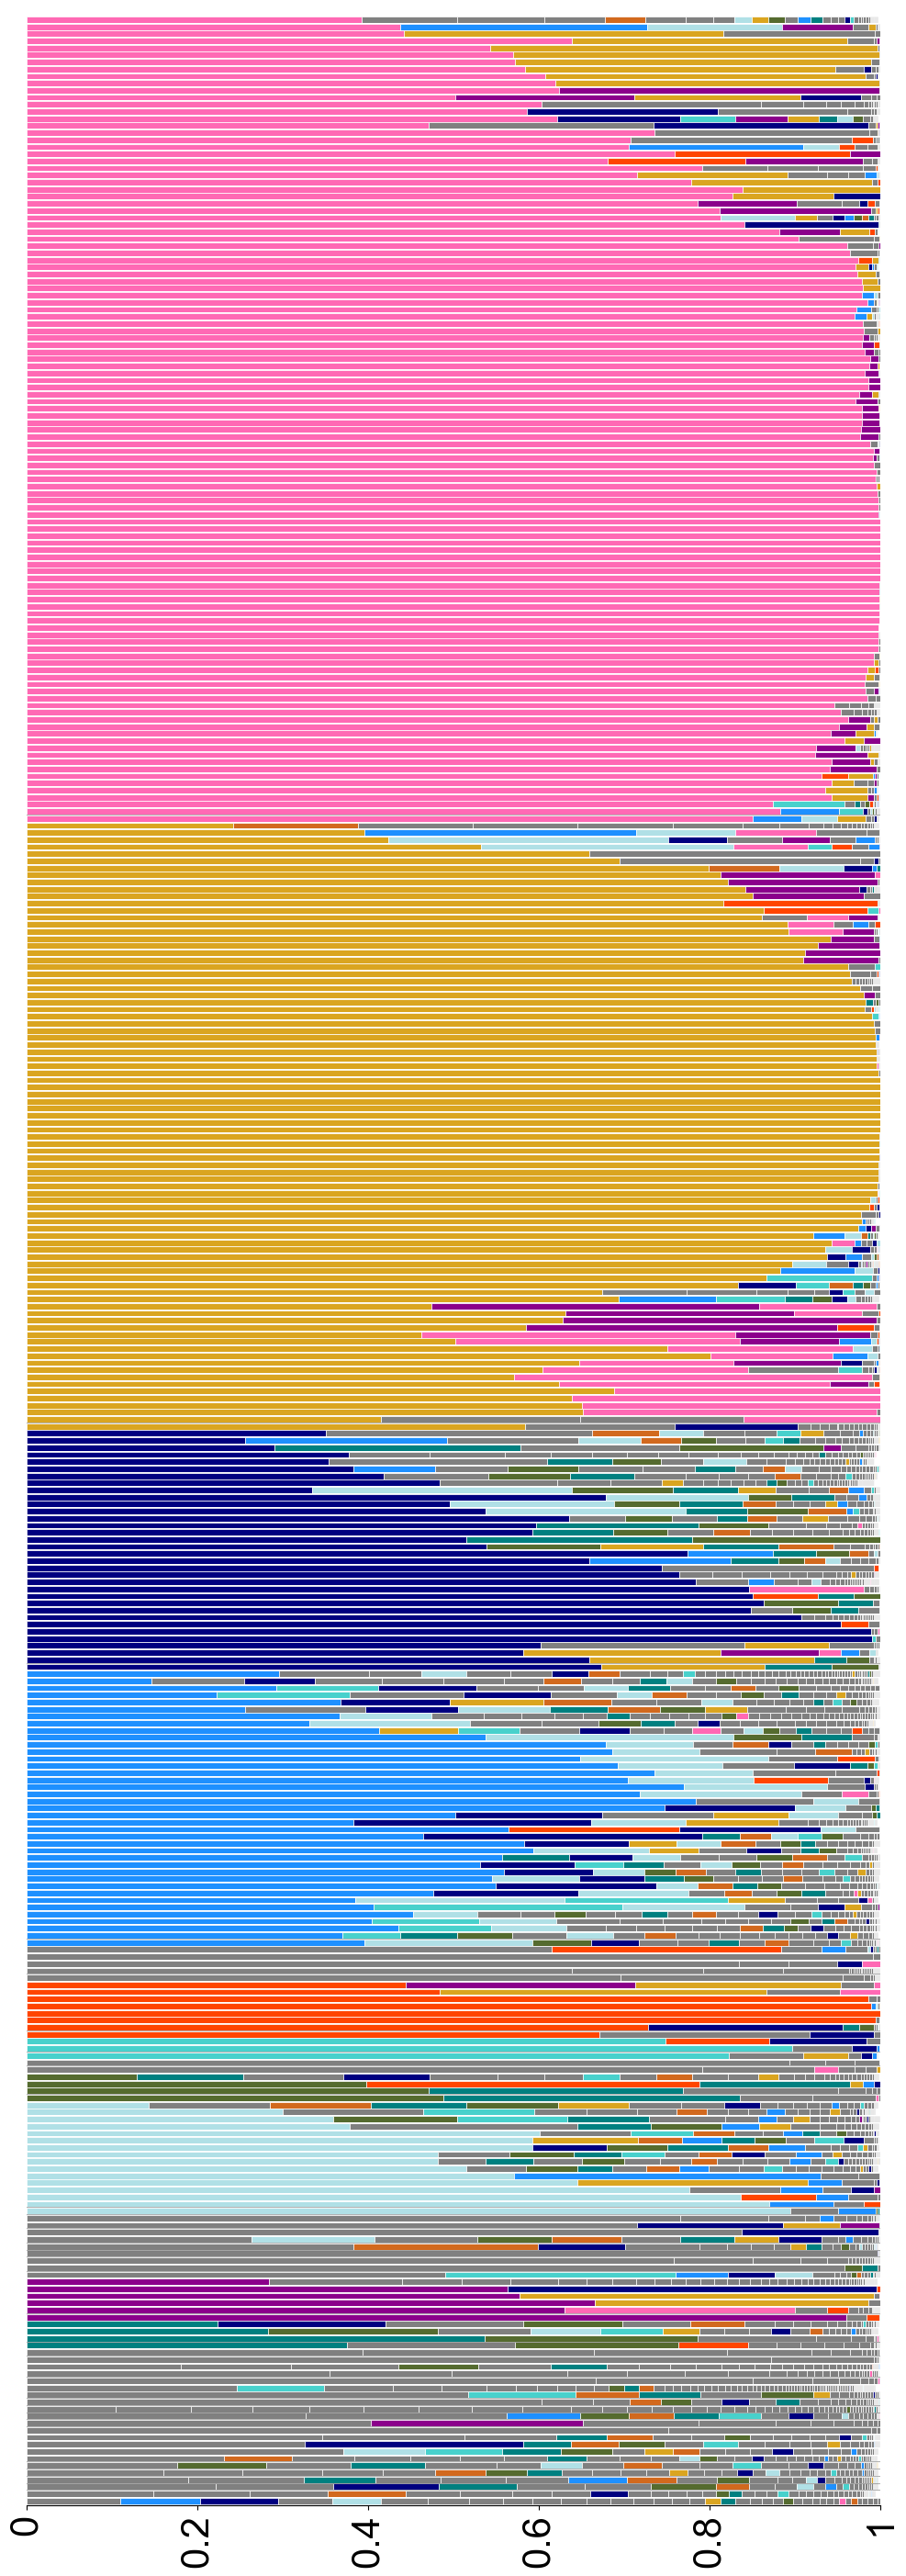

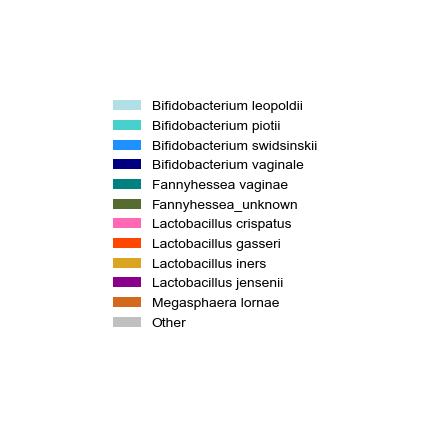

In [10]:


def plot_relative_abundance_stacked_bars(rel_abund):
    """
    Create horizontal stacked bar charts for relative abundance data.
    Samples are grouped by dominant species, then ordered by similarity within groups.
    
    Parameters:
    rel_abund: pandas DataFrame with samples as rows and species as columns
    """
    
    n_samples = len(rel_abund)
    threshold_samples = 0.05 * n_samples  # 5% of samples
    
    abundant_samples_per_species = (rel_abund > 0.05).sum()
    rare_species = abundant_samples_per_species[abundant_samples_per_species < threshold_samples].index
    common_species = abundant_samples_per_species[abundant_samples_per_species >= threshold_samples].index
    
    
    dominant_species = rel_abund.idxmax(axis=1)  
    
    groups = {}
    for sample, dom_species in dominant_species.items():
        if dom_species not in groups:
            groups[dom_species] = []
        groups[dom_species].append(sample)
    
    
    sample_order = []
    
    for dom_species, group_samples in groups.items():
        if len(group_samples) == 1:
            # If only one sample in group, just add it
            sample_order.extend(group_samples)
        else:
            # Order by similarity within the group
            group_data = rel_abund.loc[group_samples]
            
            # Calculate Bray-Curtis dissimilarity within group
            distances = pdist(group_data.values, metric='braycurtis')
            
            # Handle case where all samples are identical (distance = 0)
            if np.all(distances == 0):
                # If all samples are identical, use original order
                group_order = group_samples
            else:
                linkage_matrix = linkage(distances, method='average')
                
                # Get the order of samples from the dendrogram
                dend = dendrogram(linkage_matrix, no_plot=True)
                group_order = [group_samples[i] for i in dend['leaves']]
            
            sample_order.extend(group_order)
    
    all_dominant_species = set(dominant_species.values)    
    dominant_common = [sp for sp in common_species if sp in all_dominant_species]
    non_dominant_common = [sp for sp in common_species if sp not in all_dominant_species]
    
    
    n_dominant = len(dominant_common)
    if n_dominant > 0:
        dominant_colors = plt.cm.tab10(np.linspace(0, 1, min(n_dominant, 10)))
        if n_dominant > 10:
            extra_colors = plt.cm.tab20(np.linspace(0, 1, n_dominant - 10))
            dominant_colors = np.vstack([dominant_colors, extra_colors])
        
        for i, species in enumerate(sorted(dominant_common)):
            color_dict_mine[species] = dominant_colors[i]
    
    n_non_dominant = len(non_dominant_common)
    if n_non_dominant > 0:
        non_dominant_colors = plt.cm.Set3(np.linspace(0, 1, n_non_dominant))
        for i, species in enumerate(sorted(non_dominant_common)):
            color_dict_mine[species] = non_dominant_colors[i]
    
    # Gray color for rare species
    gray_color = 'silver'
    for species in rare_species:
        color_dict_mine[species] = gray_color
    
    n_samples = len(rel_abund)
    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 0.1 * n_samples))
    

    
    group_boundaries = []
    current_pos = 0
    
    for i, sample_name in enumerate(sample_order):
        ax = axes[i]
        sample_data = rel_abund.loc[sample_name]
        
        current_dominant = dominant_species[sample_name]
        if i == 0 or dominant_species[sample_order[i-1]] != current_dominant:
            group_boundaries.append(i)
            if i > 0:
                axes[i-1].axhline(y=0.5, color='black', linewidth=1.5, alpha=0.3)
        
        sample_data_sorted = sample_data.sort_values(ascending=False)
        
        left = 0
        for species, abundance in sample_data_sorted.items():
            if abundance > 0:  
                color = color_dict_mine.get(code_to_name[species], '#808080')
                ax.barh(0, abundance, left=left, color=color, 
                       edgecolor='white', linewidth=0.5, label=species)
                left += abundance
        
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.5, 0.5)
        ax.set_ylabel('', rotation=0, ha='right', va='center')
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        if i < n_samples - 1:
            ax.set_xticks([])
            ax.spines['bottom'].set_visible(False)
        else:
            ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1],labels=[0, 0.2, 0.4, 0.6, 0.8, 1], rotation=90)
            ax.set_xlabel('')
            # ax.set_xlabel('Relative Abundance')

    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=-0.1)
    fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
    plt.savefig(f'{fig_dir}/figure_S3.png', format='png', dpi=600, bbox_inches="tight")


    # Step 6: Create a legend
    fig_legend, ax_legend = plt.subplots(figsize=(5, 5))
    
    # Create legend entries
    legend_elements = []
    labels = []
    
    dominant_common_sorted = sorted([sp for sp in common_species if sp in all_dominant_species])
    non_dominant_common_sorted = sorted([sp for sp in common_species if sp not in all_dominant_species])


    legend_species = sorted([code_to_name[i] for i in dominant_common_sorted + non_dominant_common_sorted])

    for species in legend_species:
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, 
                                           facecolor=color_dict_mine[species]))
        labels.append(f'{species}')
    
    if len(rare_species) > 0:
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, 
                                           facecolor='silver'))
        labels.append(f'Other')
    
    n_cols = min(4, max(1, len(legend_elements) // 10))
    legend = ax_legend.legend(handles=legend_elements, labels=labels, 
                             loc='center', ncol=n_cols, 
                             bbox_to_anchor=(0.5, 0.5),
                             fontsize=10, frameon=False)
    
    ax_legend.axis('off')

    
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/figure_S3_legend.png', format='png', dpi=600, bbox_inches="tight")

    plt.show()
    
    return sample_order, rare_species, common_species, groups

g = plot_relative_abundance_stacked_bars(rel_abund)

### Select prevalent species found in both VMGC and GTDB (1:1 mapping across GTDB versions)

In [11]:
mapping = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/MIDAS_VMGC_species_mapping.csv')
mapping = mapping.set_index('VMGC_species_id')

In [12]:
sp_mapping = mapping['MIDAS_species_id'].to_dict()

VMGC_to_MIDAS = {}
VMGC_to_species_name = {}
MIDAS_to_species_name = {}

MIDAS_sp_to_keep = []
VMGC_sp_to_keep = []

for v, m in sp_mapping.items():
    
    if not pd.isna(v) and not pd.isna(m):
        VMGC_to_MIDAS[int(v)] = int(m) 
        
        sp_name = mapping.loc[v]['VMGC_species']
        
        if isinstance(sp_name, pd.Series):
            sp_name = ';'.join(sp_name.unique().tolist()).strip(';')
        
        VMGC_to_species_name[int(v)] = sp_name
        MIDAS_to_species_name[int(m)] = sp_name
        VMGC_sp_to_keep += [v]
        MIDAS_sp_to_keep += [m]

len(VMGC_to_species_name), len(VMGC_to_MIDAS)

(390, 390)

In [15]:
gtdb_rel_abund = pd.read_csv(f'{base_dir}/cervical_dysplasia/MIDAS3/GTDB_ref/results_C90/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
gtdb_rel_abund = gtdb_rel_abund.loc[gtdb_rel_abund.index.intersection(MIDAS_sp_to_keep)]
gtdb_rel_abund = gtdb_rel_abund[gtdb_rel_abund.columns.intersection(metadata.index)]

In [16]:
gtdb_prev = (gtdb_rel_abund > 0.05).astype(int)
gtdb_prev = gtdb_prev[gtdb_prev.sum(axis=1) > metadata.shape[0]*0.05]
gtdb_most_prev = gtdb_prev.sum(axis=1).sort_values(ascending=False).to_frame(name='num_samples')
gtdb_most_prev['species'] = gtdb_most_prev.index.astype(int).map(MIDAS_to_species_name)
gtdb_most_prev

,num_samples,species
species_id,,
100122,135,Lactobacillus crispatus
100505,120,Lactobacillus iners
100323,78,Bifidobacterium vaginale
103895,65,Fannyhessea vaginae
100515,35,Lactobacillus jensenii
126123,26,KA00274 sp902373515
100460,20,Lactobacillus gasseri


In [17]:
set(gtdb_most_prev['species'].values).symmetric_difference(set(vmgc_most_prev['species'].values))

{'Bifidobacterium leopoldii',
 'Bifidobacterium piotii',
 'Bifidobacterium swidsinskii',
 'Fannyhessea_unknown',
 'KA00274 sp902373515',
 'Megasphaera lornae'}

### Save species list for combined analysis

In [18]:
merged = gtdb_most_prev.reset_index().merge(vmgc_most_prev.reset_index(), on='species', suffixes=('_GTDB','_VMGC')).set_index('species')
merged

,species_id_GTDB,num_samples_GTDB,species_id_VMGC,num_samples_VMGC
species,,,,
Lactobacillus crispatus,100122,135,988598,135
Lactobacillus iners,100505,120,240891,121
Bifidobacterium vaginale,100323,78,783244,78
Fannyhessea vaginae,103895,65,619501,43
Lactobacillus jensenii,100515,35,571325,35
Lactobacillus gasseri,100460,20,611554,20


In [19]:
merged.to_csv('shared_species_for_analysis.csv')

### Make sure MIDAS genomes map to the same species in the later (214.1) GTDB version

In [22]:
gtdb_metadata = pd.read_csv(f'{base_dir}/GTDB/GTDB_metadata/bac120_metadata_r214.tsv.gz', compression='gzip', sep='\t')
gtdb_metadata.index = gtdb_metadata['accession'].str.replace('GB_','').str.replace('RS_','')
gtdb_metadata['accession_no_version'] = gtdb_metadata['accession'].str.replace('GB_','').str.replace('RS_','').str.split('.', expand=True)[0]
gtdb_all_genomes = gtdb_metadata.index.tolist()
gtdb_metadata.head()

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/2700999158.py:1: DtypeWarning: Columns (61,63,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_metadata = pd.read_csv(f'{base_dir}/GTDB/GTDB_metadata/bac120_metadata_r214.tsv.gz', compression='gzip', sep='\t')


,accession,ambiguous_bases,checkm_completeness,checkm_contamination,checkm_marker_count,checkm_marker_lineage,checkm_marker_set_count,checkm_strain_heterogeneity,coding_bases,coding_density,...,ssu_silva_blast_bitscore,ssu_silva_blast_evalue,ssu_silva_blast_perc_identity,ssu_silva_blast_subject_id,ssu_silva_taxonomy,total_gap_length,trna_aa_count,trna_count,trna_selenocysteine_count,accession_no_version
accession,,,,,,,,,,,,,,,,,,,,,
GCF_001206855.1,RS_GCF_001206855.1,14,99.60,0.91,761,g__Streptococcus (UID584),238,50.00,1827337,86.246727,...,2844,0,99.935,CP028436.1781495.1783046,Bacteria;Firmicutes;Bacilli;Lactobacillales;St...,21,19,35,0,GCF_001206855
GCF_001108865.1,RS_GCF_001108865.1,13,99.39,0.34,761,g__Streptococcus (UID584),238,33.33,1852015,86.277715,...,2844,0,99.935,AKVY01000001.1976120.1977665,Bacteria;Firmicutes;Bacilli;Lactobacillales;St...,0,19,38,0,GCF_001108865
GCF_000730125.1,RS_GCF_000730125.1,30,100.00,0.92,476,f__Bifidobacteriaceae (UID1462),217,0.00,2212698,86.271453,...,2811,0,100,CP008885.1576966.1578495,Bacteria;Actinobacteriota;Actinobacteria;Bifid...,619,19,55,0,GCF_000730125
GCF_000950275.1,RS_GCF_000950275.1,0,99.45,0.53,921,f__Vibrionaceae (UID4865),366,0.00,4128151,84.994806,...,1210,0,100,KY272023.1.1437,Bacteria;Proteobacteria;Gammaproteobacteria;En...,0,17,77,1,GCF_000950275
GCF_000468955.1,RS_GCF_000468955.1,0,100.00,0.00,472,o__Lactobacillales (UID543),265,0.00,2107260,86.823994,...,2848,0,99.935,CP003157.2105633.2107180,Bacteria;Firmicutes;Bacilli;Lactobacillales;St...,0,19,60,0,GCF_000468955


In [23]:
midas_genomes = pd.read_csv(f'{base_dir}/GTDB/GTDB_genomes_in_MIDAS.tsv', sep='\t')
midas_species_ids = merged['species_id_GTDB'].tolist()
midas_genomes = midas_genomes[midas_genomes['species'].isin(midas_species_ids)]
midas_genomes['species_name'] = midas_genomes['species'].map(merged.reset_index().set_index('species_id_GTDB')['species'])

midas_genomes_accessions = midas_genomes['genome'].tolist()
midas_genomes.head()

,genome,species,representative,genome_is_representative,species_name
136619,GCA_000466885.2,100122,GCF_002088015.1,0,Lactobacillus crispatus
136620,GCA_001311685.1,100122,GCF_002088015.1,0,Lactobacillus crispatus
136621,GCA_014654865.1,100122,GCF_002088015.1,0,Lactobacillus crispatus
136622,GCA_900452495.1,100122,GCF_002088015.1,0,Lactobacillus crispatus
136623,GCF_000091765.1,100122,GCF_002088015.1,0,Lactobacillus crispatus


In [24]:
midas_to_gtdb = {}
for g in midas_genomes_accessions:
    
    if g in gtdb_all_genomes:
        midas_to_gtdb[g] = g

    elif g.startswith('GCA') and g.replace('GCA', 'GCF') in gtdb_all_genomes:
        midas_to_gtdb[g] = g.replace('GCA', 'GCF')

    elif g.startswith('GCF') and g.replace('GCF', 'GCA') in gtdb_all_genomes:
        midas_to_gtdb[g] = g.replace('GCF', 'GCA')

    else:
        shortened = g.split('.')[0]
        no_version = gtdb_metadata[gtdb_metadata['accession_no_version'].isin([shortened, shortened.replace('GCF', 'GCA'), shortened.replace('GCA', 'GCF')]) ]
        if no_version.shape[0] > 0:
            midas_to_gtdb[g] = no_version.index[0]
        else:
            print(g)
            
            


In [25]:
len(midas_to_gtdb)

275

In [26]:
gtdb_214_tax = gtdb_metadata.loc[list(midas_to_gtdb.values())][['gtdb_taxonomy']]
gtdb_214_tax['species_214'] = gtdb_214_tax['gtdb_taxonomy'].str.split(';s__', expand=True)[1]

In [27]:
midas_genomes['gtdb214_genome_id'] = midas_genomes['genome'].map(midas_to_gtdb)
midas_genomes['gtdb214_species'] = midas_genomes['gtdb214_genome_id'].map(gtdb_214_tax['species_214'])
midas_genomes

,genome,species,representative,genome_is_representative,species_name,gtdb214_genome_id,gtdb214_species
136619,GCA_000466885.2,100122,GCF_002088015.1,0,Lactobacillus crispatus,GCF_000466885.3,Lactobacillus crispatus
136620,GCA_001311685.1,100122,GCF_002088015.1,0,Lactobacillus crispatus,GCA_001311685.1,Lactobacillus crispatus
136621,GCA_014654865.1,100122,GCF_002088015.1,0,Lactobacillus crispatus,GCF_014654865.1,Lactobacillus crispatus
136622,GCA_900452495.1,100122,GCF_002088015.1,0,Lactobacillus crispatus,GCA_900452495.1,Lactobacillus crispatus
136623,GCF_000091765.1,100122,GCF_002088015.1,0,Lactobacillus crispatus,GCF_000091765.1,Lactobacillus crispatus
...,...,...,...,...,...,...,...
193215,GCF_000159235.2,103895,GCF_000159235.2,1,Fannyhessea vaginae,GCF_000159235.2,Fannyhessea vaginae
193216,GCF_000178335.1,103895,GCF_000159235.2,0,Fannyhessea vaginae,GCF_000178335.1,Fannyhessea vaginae
193217,GCF_001049775.1,103895,GCF_000159235.2,0,Fannyhessea vaginae,GCA_001049775.1,Fannyhessea vaginae
193218,GCF_001562845.1,103895,GCF_000159235.2,0,Fannyhessea vaginae,GCA_001562845.1,Fannyhessea vaginae


In [28]:
midas_genomes[midas_genomes['species_name'] != midas_genomes['gtdb214_species']]

,genome,species,representative,genome_is_representative,species_name,gtdb214_genome_id,gtdb214_species


### Make combined list of genomes, making sure genomes are only listed once even if found in both VMGC and GTDB

In [29]:
vmgc_genomes = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/genomes.tsv', sep='\t')
vmgc_genomes = vmgc_genomes[vmgc_genomes['species'].isin(merged['species_id_VMGC'].values)]
vmgc_genomes.head()

vmgc_genomes['simple'] = vmgc_genomes['genome'].str.replace('GCF', '').str.replace('GCA', '')

In [30]:
shared_genomes = [i for i in vmgc_genomes['genome'].values if i in midas_genomes['genome'].values or i in midas_genomes['gtdb214_genome_id'].values]
vmgc_only_genomes = [i for i in vmgc_genomes['genome'].values if i not in midas_genomes['genome'].values and i not in midas_genomes['gtdb214_genome_id'].values]
gtdb_only_genomes = [i.split(';')[0] for i in (midas_genomes['genome'] + ';' + midas_genomes['gtdb214_genome_id']).values if i.split(';')[0] not in shared_genomes and i.split(';')[1] not in shared_genomes]

len(shared_genomes), len(vmgc_only_genomes), len(gtdb_only_genomes), vmgc_genomes.shape[0], midas_genomes.shape[0]

(96, 4651, 179, 4747, 275)

In [31]:
gtdb_genomes = midas_genomes[midas_genomes['genome'].isin(gtdb_only_genomes)]
gtdb_genomes.shape

(179, 7)

### Save accessions of GTDB-only genomes so I can download them

In [32]:
to_write = '\n'.join(gtdb_only_genomes)
with open(f'{base_dir}/compare_VMGC_GTDB/combined_db_build/GTDB_genome_accessions.txt', 'w') as f:

    f.write(to_write)



In [33]:
gtdb_genomes = gtdb_genomes.rename(columns={'species':'GTDB_species'})
gtdb_to_vmgc_species = merged.set_index('species_id_GTDB')['species_id_VMGC']

In [34]:
gtdb_genomes['species'] = gtdb_genomes['GTDB_species'].map(gtdb_to_vmgc_species)
gtdb_genomes['fasta_path'] = gtdb_genomes['genome'].apply(lambda x: f'/wynton/group/sirota/clairedubin/VMGC_GTDB_combined_db/GTDB_genomes/GTDB_genomes/{x}.fna')

In [35]:
gtdb_genomes['database'] = 'GTDB'
vmgc_genomes['database'] = vmgc_genomes['genome'].apply(lambda x: 'shared' if x in shared_genomes else 'VMGC')

In [36]:
vmgc_quality_info = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t', index_col=0)
vmgc_quality_info

,BioSample_ID,Collection/isolation_source,Type,Genome_size_(bp),No._of_contigs,N50_length_(bp),N90_length_(bp),Max_length_(bp),%_GC_content,%_Completeness,%_Contamination,Quality_score,Clade_separation_score_(GUNC),Presence_of_5S_rRNA,Presence_of_16S_rRNA,Presence_of_23S_rRNA,No._of_tRNA,Genome_quality,Species-level_genomic_bin_(95%_ANI)
Genome_ID,,,,,,,,,,,,,,,,,,,
ERR10897564.mbin.1,ERR10897564,vaginal swab,MAG,1087166,64,21321,9170,106681,32.47,92.37,0.36,90.57,0.00,Y,N,N,16,high-quality,SGB001
ERR10897570.mbin.1,ERR10897570,vaginal swab,MAG,946879,36,35494,16114,91025,44.15,69.36,0.05,69.11,0.03,N,N,N,14,medium-quality,SGB020
ERR10897572.mbin.2,ERR10897572,vaginal swab,MAG,634492,160,4095,2310,18976,32.86,51.82,0.05,51.57,0.00,Y,N,N,12,medium-quality,SGB001
ERR10897572.mbin.3,ERR10897572,vaginal swab,MAG,1042602,73,18747,7657,84304,37.32,59.34,0.17,58.49,0.00,N,N,N,16,medium-quality,SGB006
ERR10897573.mbin.4,ERR10897573,vaginal swab,MAG,2066518,406,5736,2674,38890,42.40,75.82,1.43,68.67,0.00,N,N,N,16,medium-quality,SGB014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR6748217.mbin.3,SRR6748217,vagina,MAG,931180,64,20011,7687,67941,42.62,62.77,1.32,56.17,0.41,N,N,N,15,medium-quality,SGB026
SRR6748218.mbin.1,SRR6748218,vagina,MAG,1247995,331,3923,2334,16514,39.46,61.40,0.54,58.70,0.00,N,N,N,13,medium-quality,SGB025
SRR6748219.mbin.1,SRR6748219,vagina,MAG,1607896,18,136134,37494,327330,41.26,99.99,0.67,96.64,0.16,N,N,N,20,high-quality,SGB004


In [37]:
gtdb_genome_metadata = pd.read_csv(f'{base_dir}/GTDB/GTDB_metadata/bac120_metadata_r202.tsv.gz', compression='gzip', sep='\t', )
gtdb_genome_metadata = gtdb_genome_metadata[gtdb_genome_metadata['accession'].str.contains('|'.join(gtdb_genomes['genome'].tolist()))].set_index('accession')

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/2280591828.py:1: DtypeWarning: Columns (61,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_genome_metadata = pd.read_csv(f'{base_dir}/GTDB/GTDB_metadata/bac120_metadata_r202.tsv.gz', compression='gzip', sep='\t', )


In [38]:
merged = pd.concat([vmgc_genomes, gtdb_genomes.drop(columns=['genome','gtdb214_species', 'species_name']).rename(columns={'gtdb214_genome_id':'genome'})])
merged = merged.drop(columns=['GTDB_species','simple'])
merged.head()

,genome,species,representative,genome_is_representative,fasta_path,database
4,GCF_000439915.2,611554,GCF_000439915.2,1,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,shared
8,SRR17284223.mbin.1,240891,SRR17284223.mbin.1,1,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,VMGC
9,SRR10258542.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,VMGC
12,MG329.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,VMGC
17,P10709414.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,VMGC


In [39]:
merged.shape

(4926, 6)

In [40]:
merged['database'].value_counts()

database
VMGC      4651
GTDB       179
shared      96
Name: count, dtype: int64

In [41]:
len(merged['genome'].unique())

4926

### Select new representative genome

Picking genome with higher completeness between GTDB/VMGC representatives

In [42]:

new_reps = {}
for sp in merged['species'].unique():

    temp = merged[merged['species'] == sp]

    reps = temp[temp['genome_is_representative']==1].sort_values('database')

    if len(reps) == 1:
        new_reps[sp] = reps['genome'].values[0]
        continue
    
    gtdb_rep, vmgc_rep = reps['genome'].tolist()
    
    vmgc_completeness = vmgc_quality_info.loc[vmgc_rep]['%_Completeness']
    gtdb_completeness = gtdb_genome_metadata[gtdb_genome_metadata.index.str.contains(gtdb_rep)]['checkm_completeness'][0]

    if vmgc_completeness > gtdb_completeness:
        new_reps[sp] = vmgc_rep

    else: 
        new_reps[sp] = gtdb_rep

new_reps



/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/3863495328.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gtdb_completeness = gtdb_genome_metadata[gtdb_genome_metadata.index.str.contains(gtdb_rep)]['checkm_completeness'][0]


{np.int64(611554): 'GCF_000439915.2',
 np.int64(240891): 'SRR17284223.mbin.1',
 np.int64(988598): 'GCF_000162255.1',
 np.int64(571325): 'GCF_027155795.1',
 np.int64(619501): 'GCF_001562845.1',
 np.int64(783244): 'ERR10897722.mbin.1'}

In [43]:
merged['representative'] = merged['species'].map(new_reps)
merged['genome_is_representative'] = (merged['genome'] == merged['representative']).astype(int)
merged.groupby('species')['representative'].nunique()

species
240891    1
571325    1
611554    1
619501    1
783244    1
988598    1
Name: representative, dtype: int64

In [44]:
merged.groupby('species')['genome_is_representative'].value_counts()

species  genome_is_representative
240891   0                           1886
         1                              1
571325   0                            349
         1                              1
611554   0                            227
         1                              1
619501   0                            786
         1                              1
783244   0                            733
         1                              1
988598   0                            939
         1                              1
Name: count, dtype: int64

In [45]:
merged[['species', 'database']].value_counts().sort_index()

species  database
240891   GTDB          11
         VMGC        1856
         shared        20
571325   GTDB          23
         VMGC         321
         shared         6
611554   GTDB          26
         VMGC         195
         shared         7
619501   GTDB           1
         VMGC         782
         shared         4
783244   GTDB          34
         VMGC         685
         shared        15
988598   GTDB          84
         VMGC         812
         shared        44
Name: count, dtype: int64

### Remove 3 genomes that were unable to be downloaded from NCBI

In [47]:
skip = ['GCF_007786035.1','GCF_002863425.1','GCF_002862015.1']

In [49]:
merged= merged[~merged['genome'].isin(skip)]
merged.shape

(4923, 6)

In [50]:
merged.drop(columns='database').to_csv(f'{base_dir}/compare_VMGC_GTDB/combined_db_build/combined_genomes.tsv', sep='\t', index=False)

In [51]:
merged.to_csv(f'{base_dir}/compare_VMGC_GTDB/combined_db_build/combined_genomes_with_database.tsv', sep='\t', index=False)

In [52]:
merged['species'].value_counts()

species
240891    1887
988598     940
619501     787
783244     733
571325     349
611554     227
Name: count, dtype: int64

### Make input file for GTDB rarefaction

In [53]:
all_gtdb_genomes = merged[merged['database'].isin(['shared', 'GTDB'])]

all_gtdb_genomes['GTDB_species'] = all_gtdb_genomes['species'].map(VMGC_to_MIDAS)

gtdb_species_to_rep = midas_genomes.drop_duplicates('species').set_index('species')['representative']

all_gtdb_genomes['representative'] = all_gtdb_genomes['GTDB_species'].map(gtdb_species_to_rep)
all_gtdb_genomes['genome_is_representative'] = (all_gtdb_genomes['genome'] == all_gtdb_genomes['representative']).astype(int)

all_gtdb_genomes.drop(columns=['database','GTDB_species']).to_csv(f'{base_dir}/compare_VMGC_GTDB/rarefaction/GTDB_genomes_for_rarefaction.tsv', sep='\t', index=False)

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/2894279546.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_gtdb_genomes['GTDB_species'] = all_gtdb_genomes['species'].map(VMGC_to_MIDAS)
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/2894279546.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_gtdb_genomes['representative'] = all_gtdb_genomes['GTDB_species'].map(gtdb_species_to_rep)
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_2791/2894279546.py:8: 